In [6]:
import pyreadr
from sklearn.preprocessing import StandardScaler
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.cluster import AgglomerativeClustering
# Load the RData file
result = pyreadr.read_r('../data/portarthur_sd_df_2019.rdata')

# Extract the dataframe (assuming there's only one object inside)
df = list(result.values())[0]

# View the structure
print(df.columns)
print(df.head())


Index(['origin_census_block_group', 'device_count', 'destination_cbg',
       'destination_device_count', 'year', 'uid', 'from_cnt', 'to_cnt'],
      dtype='object')
  origin_census_block_group device_count destination_cbg  \
0              482450117002           98    482450111011   
1              482450117002           98    481990303003   
2              482450117002           98    482450003082   
3              482450117002           98    482450109022   
4              482450117002           98    482450003071   

  destination_device_count    year    uid from_cnt to_cnt  
0                        1  2019.0  100.0    48245  48245  
1                        1  2019.0  100.0    48245  48199  
2                        1  2019.0  100.0    48245  48245  
3                        1  2019.0  100.0    48245  48245  
4                        2  2019.0  100.0    48245  48245  


In [7]:
# Step 2a: Filter data where people stay in their own CBG
df_residence = df[df['origin_census_block_group'] == df['destination_cbg']].copy()

# Step 2b: Convert uid to integer (to sort and handle dates if needed)
df_residence['uid'] = df_residence['uid'].astype(int)

# Step 2c: Group by origin_cbg and uid (date), and sum the devices that stayed within the home CBG
daily_residence_activity = df_residence.groupby(
    ['origin_census_block_group', 'uid']
)['destination_device_count'].sum().reset_index()
# Rename for clarity
daily_residence_activity.columns = ['cbg', 'day', 'residential_device_count']
# View result
print(daily_residence_activity.head())

            cbg  day residential_device_count
0  481990301001    1                       55
1  481990301001    2                       58
2  481990301001    3                       54
3  481990301001    4                       55
4  481990301001    5                       49


In [8]:
# Define baseline period
baseline_start = 260
baseline_end = 290

# Filter baseline window
baseline_df = daily_residence_activity[
    (daily_residence_activity['day'] >= baseline_start) &
    (daily_residence_activity['day'] <= baseline_end)
]

# Convert to numeric type to avoid mean error
baseline_df['residential_device_count'] = baseline_df['residential_device_count'].astype(int)

# Compute average residential device count per CBG during baseline
baseline_avg = baseline_df.groupby('cbg')['residential_device_count'].mean().reset_index()
baseline_avg.columns = ['cbg', 'baseline_residential_device_count']

# Show result
print(baseline_avg.head())


            cbg  baseline_residential_device_count
0  481990301001                          63.774194
1  481990301002                          60.612903
2  481990301003                         123.903226
3  481990302001                         269.806452
4  481990302002                         202.612903


/var/folders/5p/7kddy16s0jqcn_ckbf5k0z3w0000gn/T/ipykernel_82556/873951495.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  baseline_df['residential_device_count'] = baseline_df['residential_device_count'].astype(int)


In [9]:
# Step 1: Merge daily activity with baseline values
resilience_df = daily_residence_activity.merge(
    baseline_avg,
    on='cbg',
    how='inner'
)

# Step 2: Calculate normalized activity A(t)
resilience_df['A_t'] = resilience_df['residential_device_count'].astype(float) / resilience_df['baseline_residential_device_count']

# Step 3: View result
print(resilience_df.head())


            cbg  day residential_device_count  \
0  481990301001    1                       55   
1  481990301001    2                       58   
2  481990301001    3                       54   
3  481990301001    4                       55   
4  481990301001    5                       49   

   baseline_residential_device_count       A_t  
0                          63.774194  0.862418  
1                          63.774194  0.909459  
2                          63.774194  0.846737  
3                          63.774194  0.862418  
4                          63.774194  0.768336  


In [10]:
# Step 1: Define disaster and recovery period
disaster_start = 260
recovery_end = 290

# Step 2: Filter for recovery window
recovery_df = resilience_df[
    (resilience_df['day'] >= disaster_start) & 
    (resilience_df['day'] <= recovery_end)
].copy()

# Step 3: Calculate RCN = ∫ (1 - A(t)) dt → approximated using sum over days
recovery_df['activity_gap'] = 1 - recovery_df['A_t']  # A_equilibrium = 1

# Step 4: Integrate per CBG
rcn_df = recovery_df.groupby('cbg')['activity_gap'].sum().reset_index()
rcn_df.columns = ['cbg', 'RCN']

# View RCN scores
print(rcn_df.head())


            cbg           RCN
0  481990301001  3.330669e-16
1  481990301002 -1.665335e-15
2  481990301003  1.332268e-15
3  481990302001  5.551115e-16
4  481990302002  1.776357e-15


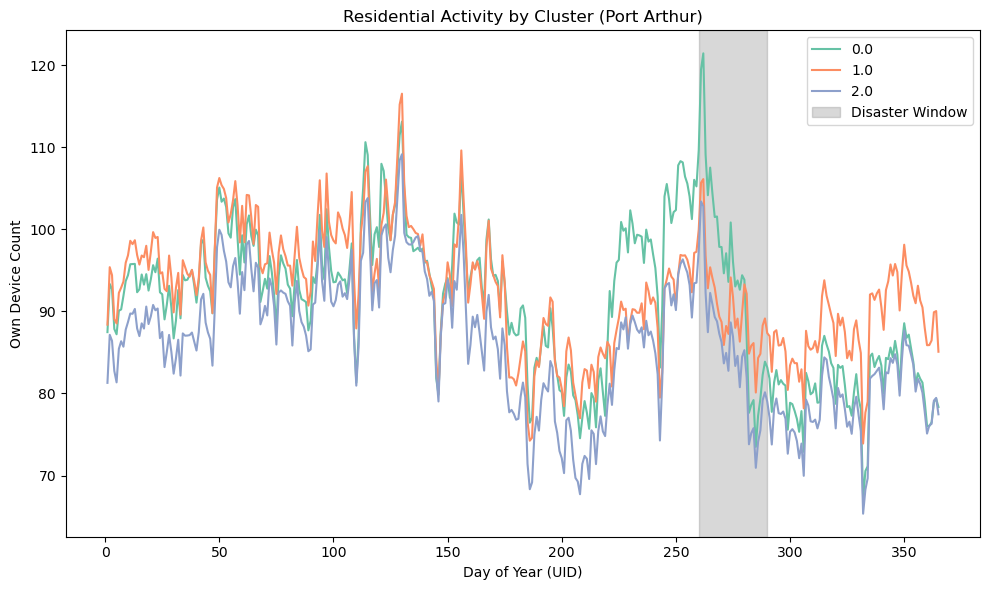

In [11]:
# Scale RCN values
scaler = StandardScaler()
rcn_scaled = scaler.fit_transform(rcn_df[['RCN']])


from sklearn.cluster import AgglomerativeClustering

# Set number of clusters (e.g., 3)
n_clusters = 3

# Fit clustering
agg_cluster = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
rcn_df['cluster'] = agg_cluster.fit_predict(rcn_scaled)
# Merge cluster labels into daily data
merged = daily_residence_activity.merge(rcn_df, on='cbg', how='left')
import matplotlib.pyplot as plt
import seaborn as sns

# Convert to numeric (fixes your error)
merged['residential_device_count'] = pd.to_numeric(merged['residential_device_count'], errors='coerce')

# Now group and compute average safely
plot_df = merged.groupby(['cluster', 'day'])['residential_device_count'].mean().reset_index()


# Plot
plt.figure(figsize=(10,6))
sns.lineplot(data=plot_df, x='day', y='residential_device_count', hue='cluster', palette='Set2')
plt.axvspan(260, 290, color='gray', alpha=0.3, label='Disaster Window')  # Shade disaster period
plt.xlabel('Day of Year (UID)')
plt.ylabel('Own Device Count')
plt.title('Residential Activity by Cluster (Port Arthur)')
plt.legend()
plt.tight_layout()
plt.show()


In [12]:
# Group by cluster and compute average RCN
rcn_per_cluster = rcn_df.groupby('cluster')['RCN'].mean().reset_index()
print(rcn_per_cluster)


   cluster           RCN
0        0 -1.312247e-15
1        1  1.995183e-15
2        2  7.327472e-16


/var/folders/5p/7kddy16s0jqcn_ckbf5k0z3w0000gn/T/ipykernel_82556/3760299871.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='cluster', y='RCN', data=rcn_per_cluster, palette='viridis')


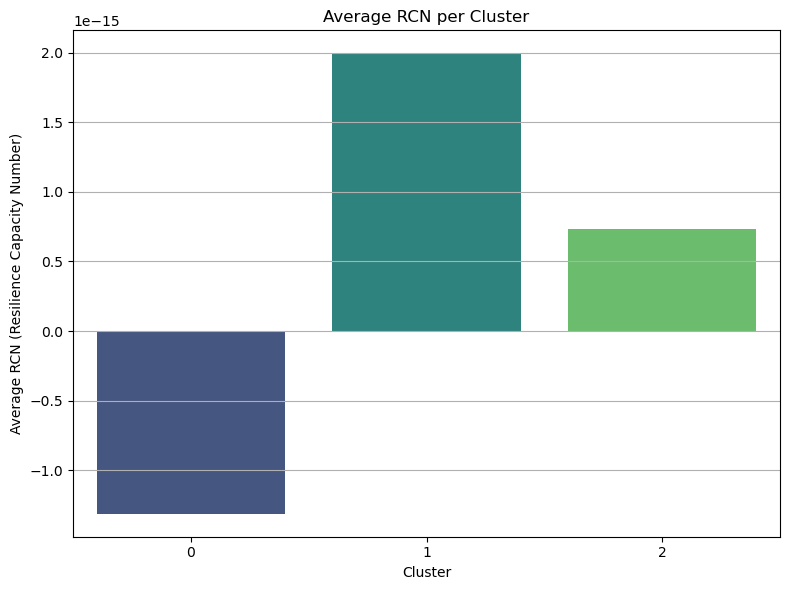

In [13]:

plt.figure(figsize=(8, 6))
sns.barplot(x='cluster', y='RCN', data=rcn_per_cluster, palette='viridis')
plt.title('Average RCN per Cluster')
plt.xlabel('Cluster')
plt.ylabel('Average RCN (Resilience Capacity Number)')
plt.grid(axis='y')
plt.tight_layout()
plt.show()
